In [1]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import pandas as pd
df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
y = df["median_house_value"]
x = df.drop("median_house_value" , axis=1)

In [3]:
df.info('ocean_proximity')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [5]:
print(len(x_train))
print(len(x_test))

16512
4128


In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


In [7]:
def build_pipeline(num_attribs, cat_attribs):
    num_pipeline = Pipeline([ 
       ( "imputer" , SimpleImputer(strategy = "median")),
        ("Scaler" , StandardScaler())
    ]) 
    cat_pipeline =Pipeline([
        ("onehot" , OneHotEncoder(handle_unknown = "ignore"))
    ])
    full_pipeline = ColumnTransformer([
        ("num" , num_pipeline, num_attribs),
        ("cat" , cat_pipeline , cat_attribs)
    ])
    return full_pipeline
    

In [8]:
num_attribs =x_train.drop("ocean_proximity", axis =1).columns.tolist()
cat_attribs =["ocean_proximity"]
pipeline = build_pipeline(num_attribs, cat_attribs)

In [9]:
x_train_prepared = pipeline.fit_transform(x_train)

In [10]:
model = LinearRegression()
model.fit(x_train_prepared, y_train)

LinearRegression()

In [11]:
x_test_prepared = pipeline.transform(x_test)
predictions = model.predict(x_test_prepared)

In [12]:
print(predictions[:5])

[ 54261.02768976 124430.91772796 255694.95828244 268208.01035997
 262975.01360647]


In [13]:
from sklearn.metrics import root_mean_squared_error
rmse = root_mean_squared_error(y_test, predictions)
print(rmse)

70059.19333925012


In [14]:
from sklearn.ensemble import RandomForestRegressor

In [15]:
model_rf = RandomForestRegressor()
model_rf.fit(x_train_prepared , y_train)
                            

RandomForestRegressor()

In [16]:
x_train_prepared = pipeline.transform(x_train)
predictions = model_rf.predict(x_train_prepared)

In [17]:
print(predictions[:5])

[107137.   375976.02 179286.    91173.    93770.  ]


In [18]:
x_test_prepared = pipeline.transform(x_test)
predictions_test = model_rf.predict(x_test_prepared)
rmse_test = root_mean_squared_error(y_test, predictions_test)
print(rmse_test)

49122.723229446616


In [19]:
results = pd.DataFrame({
    "original Price": y_test.values,
    "Predicted Price": predictions_test.astype(int)
})
results["Fark"] = (results["original Price"] - results["Predicted Price"]).astype(int)
print(results)
results.to_csv("housing_predictions.csv", index=False)


      original Price  Predicted Price   Fark
0            47700.0            50489  -2789
1            45800.0            68162 -22362
2           500001.0           470158  29843
3           218600.0           255141 -36541
4           278000.0           266954  11046
...              ...              ...    ...
4123        263300.0           209934  53366
4124        266800.0           233998  32802
4125        500001.0           498663   1338
4126         72300.0            69274   3026
4127        151500.0           170430 -18930

[4128 rows x 3 columns]


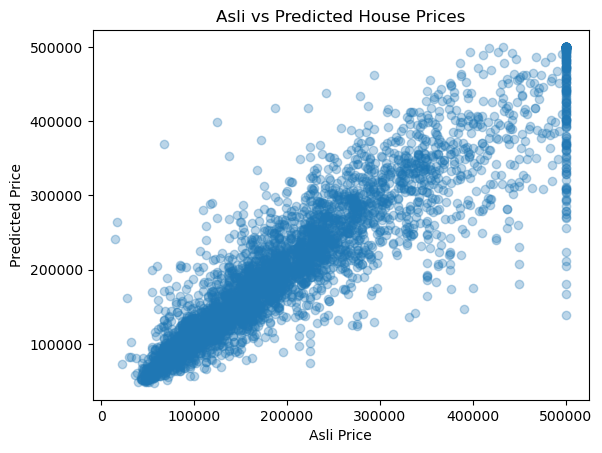

In [20]:
import matplotlib.pyplot as plt

plt.scatter(y_test, predictions_test, alpha=0.3)
plt.xlabel("Asli Price")
plt.ylabel("Predicted Price")
plt.title("Asli vs Predicted House Prices")
plt.show()

In [25]:
import joblib 
joblib.dump(model_rf, "housing_model.pkl")
joblib.dump(pipeline,"housing_pipeline.pkl")

['housing_pipeline.pkl']

In [26]:
import os 
print(os.path.exists("housing_model.pkl"))

True


In [27]:
loaded_model = joblib.load("housing_model.pkl")
loaded_pipeline = joblib.load("housing_pipeline.pkl")

In [31]:
loaded_pipeline.transform(x_test )
x_test_new = loaded_pipeline.transform(x_test )

In [32]:
loaded_model.predict(x_test_new)

array([ 50489.  ,  68162.  , 470158.41, ..., 498663.99,  69274.  ,
       170430.  ])